<a href="https://colab.research.google.com/github/antraraj441/OIBSIP/blob/main/AntraRaj_4_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
df = pd.read_csv("sentiment_analysis_dataset.csv")

Check the dataset

In [5]:
print("First 5 rows:")
print(df.head())

First 5 rows:
                                                text sentiment
0  I absolutely love this product, it works perfe...  positive
1  The service was excellent and the staff were v...  positive
2  Amazing experience, I would definitely recomme...  positive
3    The quality is great and the delivery was fast.  positive
4                  I am very happy with my purchase.  positive


In [6]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(60, 2)


In [7]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['text', 'sentiment'], dtype='object')


In [8]:
print("\nData Types:")
print(df.dtypes)


Data Types:
text         object
sentiment    object
dtype: object


In [9]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
text         0
sentiment    0
dtype: int64


Check sentiment distribution

In [10]:
print(df["sentiment"].value_counts())

sentiment
positive    20
negative    20
neutral     20
Name: count, dtype: int64


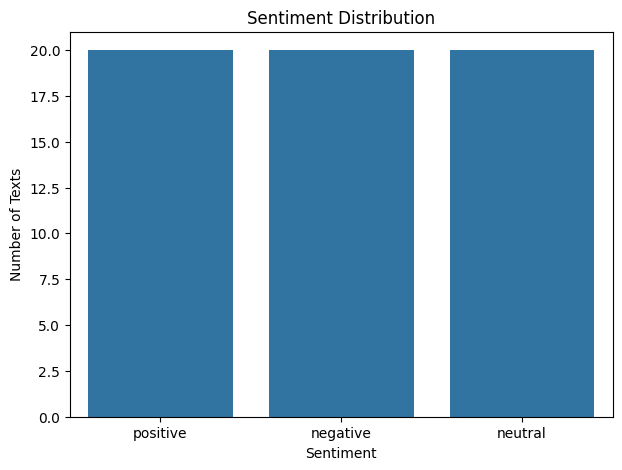

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")

plt.show()

Text preprocessing


In [12]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()


def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Split text into words
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    # Join words again
    return " ".join(words)

In [13]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [14]:
print(df[["text", "clean_text"]].head(10))

                                                text  \
0  I absolutely love this product, it works perfe...   
1  The service was excellent and the staff were v...   
2  Amazing experience, I would definitely recomme...   
3    The quality is great and the delivery was fast.   
4                  I am very happy with my purchase.   
5  This is one of the best products I have ever u...   
6            The app is easy to use and very useful.   
7     Fantastic customer service and quick response.   
8     The product looks beautiful and feels premium.   
9  Everything arrived on time and in perfect cond...   

                                      clean_text  
0         absolutely love product work perfectly  
1                service excellent staff helpful  
2  amazing experience would definitely recommend  
3                    quality great delivery fast  
4                                 happy purchase  
5                     one best product ever used  
6                         

Separate features and labels

In [15]:
X = df["clean_text"]
y = df["sentiment"]

Train/Test Split — 80/20

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 48
Testing samples: 12


TF-IDF Feature Extraction

In [18]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [19]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (48, 132)
Testing TF-IDF shape: (12, 132)


Model 1 — Naive Bayes

In [20]:
nb_model = MultinomialNB()

In [21]:
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [22]:
nb_pred = nb_model.predict(X_test_tfidf)

Evaluate Naive Bayes

In [23]:
nb_accuracy = accuracy_score(y_test, nb_pred)

nb_precision = precision_score(
    y_test,
    nb_pred,
    average="weighted"
)

nb_recall = recall_score(
    y_test,
    nb_pred,
    average="weighted"
)

nb_f1 = f1_score(
    y_test,
    nb_pred,
    average="weighted"
)

print("Naive Bayes")
print("-------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes
-------------------
Accuracy : 0.3333333333333333
Precision: 0.26666666666666666
Recall   : 0.3333333333333333
F1 Score : 0.2962962962962963


In [24]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

    negative       0.20      0.25      0.22         4
     neutral       0.60      0.75      0.67         4
    positive       0.00      0.00      0.00         4

    accuracy                           0.33        12
   macro avg       0.27      0.33      0.30        12
weighted avg       0.27      0.33      0.30        12



Naive Bayes Confusion Matrix

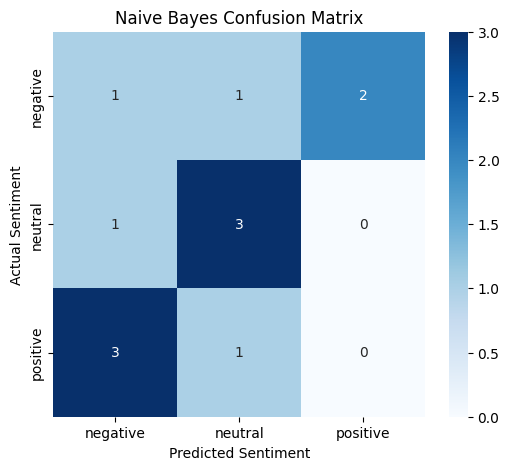

In [25]:
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

Model 2 — Logistic Regression

In [26]:
lr_model = LogisticRegression(
    max_iter=1000
)

In [27]:
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [28]:
lr_pred = lr_model.predict(X_test_tfidf)

Evaluate Logistic Regression

In [29]:
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average="weighted"
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average="weighted"
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average="weighted"
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
-------------------
Accuracy : 0.3333333333333333
Precision: 0.25
Recall   : 0.3333333333333333
F1 Score : 0.2833333333333333


In [30]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    negative       0.25      0.25      0.25         4
     neutral       0.50      0.75      0.60         4
    positive       0.00      0.00      0.00         4

    accuracy                           0.33        12
   macro avg       0.25      0.33      0.28        12
weighted avg       0.25      0.33      0.28        12



Logistic Regression Confusion Matrix

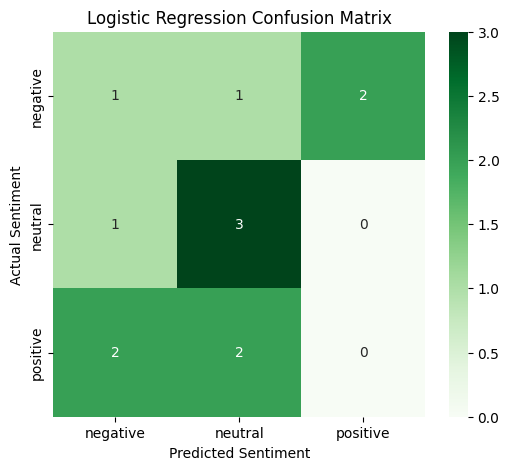

In [31]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

Compare both models

In [32]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],

    "Precision": [
        nb_precision,
        lr_precision
    ],

    "Recall": [
        nb_recall,
        lr_recall
    ],

    "F1 Score": [
        nb_f1,
        lr_f1
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.333333   0.266667  0.333333  0.296296
1  Logistic Regression  0.333333   0.250000  0.333333  0.283333


Model comparison graph

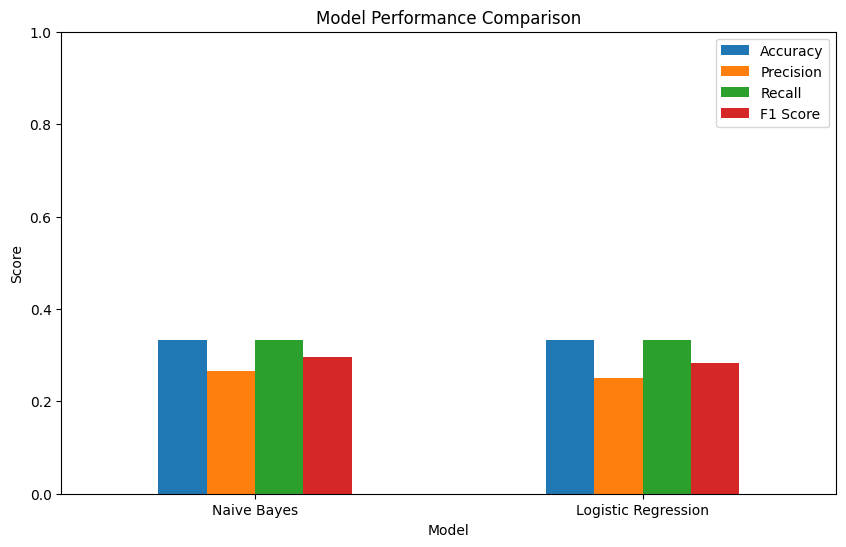

In [33]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.legend()

plt.show()

WordCloud — Positive

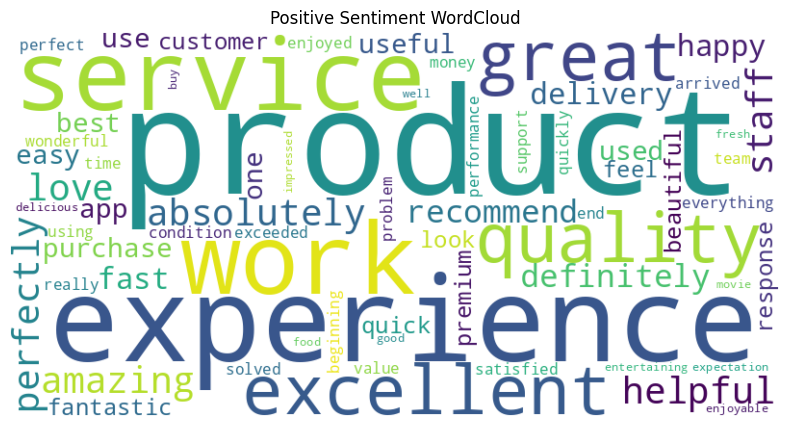

In [34]:
positive_text = " ".join(
    df[df["sentiment"] == "positive"]["clean_text"]
)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(
    wordcloud_positive,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Positive Sentiment WordCloud")

plt.show()

WordCloud — Negative

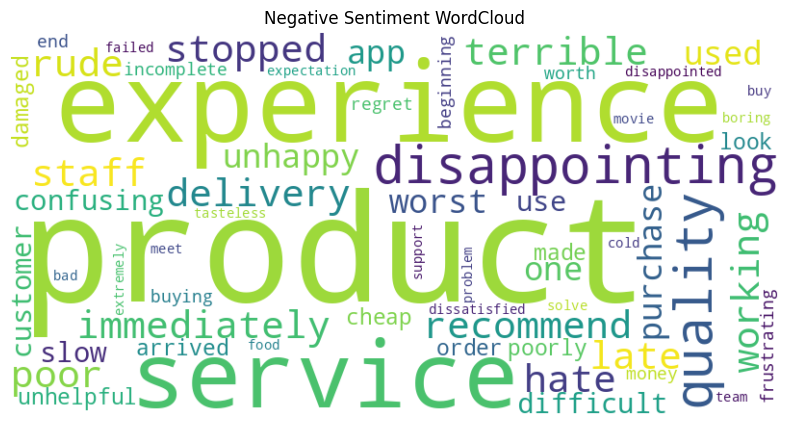

In [35]:
negative_text = " ".join(
    df[df["sentiment"] == "negative"]["clean_text"]
)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(10,5))

plt.imshow(
    wordcloud_negative,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Negative Sentiment WordCloud")

plt.show()

WordCloud — Neutral

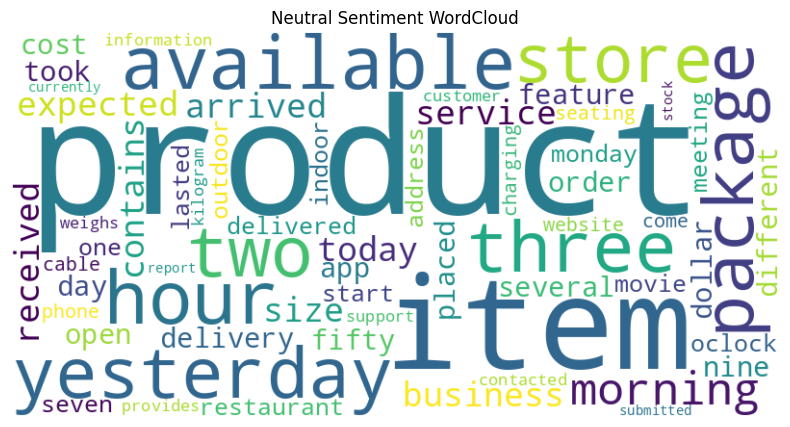

In [36]:
neutral_text = " ".join(
    df[df["sentiment"] == "neutral"]["clean_text"]
)

wordcloud_neutral = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(10,5))

plt.imshow(
    wordcloud_neutral,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Neutral Sentiment WordCloud")

plt.show()

Error Analysis — 5 examples


In [37]:
error_df = pd.DataFrame({
    "Text": X_test.values,
    "Actual": y_test.values,
    "Predicted": lr_pred
})

In [38]:
misclassified = error_df[
    error_df["Actual"] != error_df["Predicted"]
]

In [39]:
print("5 Misclassified Examples:")
print()

for index, row in misclassified.head(5).iterrows():

    print("Text:", row["Text"])
    print("Actual:", row["Actual"])
    print("Predicted:", row["Predicted"])
    print("-" * 60)

5 Misclassified Examples:

Text: support team solve problem
Actual: negative
Predicted: positive
------------------------------------------------------------
Text: movie entertaining enjoyable
Actual: positive
Predicted: neutral
------------------------------------------------------------
Text: quality great delivery fast
Actual: positive
Predicted: negative
------------------------------------------------------------
Text: app confusing difficult use
Actual: negative
Predicted: neutral
------------------------------------------------------------
Text: product look beautiful feel premium
Actual: positive
Predicted: negative
------------------------------------------------------------


Test your own sentences

In [40]:
def predict_sentiment(text):

    clean_text = preprocess_text(text)

    text_tfidf = tfidf.transform([clean_text])

    prediction = lr_model.predict(text_tfidf)

    return prediction[0]

In [41]:
print(predict_sentiment(
    "I really love this product"
))

positive


In [42]:
print(predict_sentiment(
    "This product is horrible"
))

negative


In [43]:
print(predict_sentiment(
    "The product arrived yesterday"
))

neutral


Final conclusion

## Final Conclusion

In this project, sentiment analysis was performed on text data containing
positive, negative, and neutral sentiments.

The text was preprocessed using lowercase conversion, punctuation removal,
stopword removal, and lemmatization.

TF-IDF was used to convert text into numerical features. Naive Bayes and
Logistic Regression were trained using an 80/20 train-test split.

Both models were evaluated using accuracy, precision, recall, F1-score,
and confusion matrices. The better-performing model can be selected
based on the evaluation results.

Sentiment analysis can be useful for customer reviews, product feedback,
social media monitoring, surveys, and public opinion analysis.